In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import imblearn

print("Everything is working!")

Everything is working!


In [2]:
# Load dataset from data folder inside notebooks
df = pd.read_csv("data/creditcard.csv")

# Display first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# View rows and columns
print(f"Dataset Shape: {df.shape}")

# View missing values and data types
df.info()

Dataset Shape: (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float6

In [ ]:
# Count of normal (0) vs fraudulent (1) transactions
class_counts = df['Class'].value_counts()
print("Class Distribution:")
print(class_counts)

# Percentage of fraud cases
fraud_percentage = (class_counts[1] / len(df)) * 100
print(f"\nFraud Percentage: {fraud_percentage:.3f}%")

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.173%


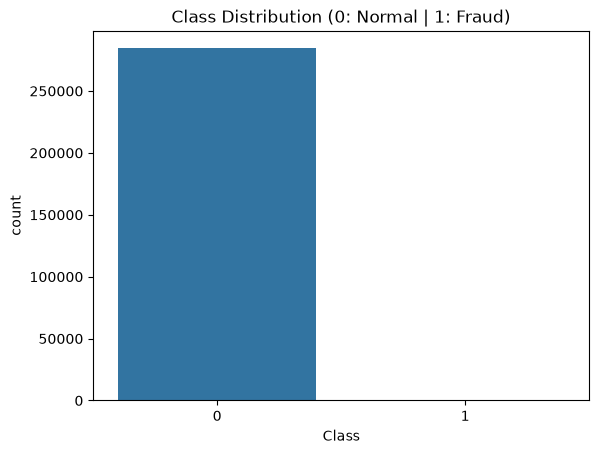

In [5]:
# Plot class counts
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0: Normal | 1: Fraud)")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Load data
df = pd.read_csv("data/creditcard.csv")

# 2. Separate features & target
X = df.drop(columns=['Time', 'Class'])
y = df['Class']

# 3. Split FIRST to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Fit Scaler ONLY on X_train, then transform both sets
scaler = StandardScaler()
X_train['scaled_amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['scaled_amount'] = scaler.transform(X_test[['Amount']])

# Drop original unscaled Amount column
X_train = X_train.drop(columns=['Amount'])
X_test = X_test.drop(columns=['Amount'])

# 5. Apply SMOTE ONLY on training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Data preprocessed and balanced without data leakage!")

Data preprocessed and balanced without data leakage!


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Time', 'Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (227845, 29)
Testing set shape: (56962, 29)


In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training fraud counts: {y_train.value_counts()[1]}")
print(f"Resampled training fraud counts: {y_train_res.value_counts()[1]}")

Original training fraud counts: 394
Resampled training fraud counts: 227451


In [17]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# -----------------------------
# 1. Train Random Forest
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)


# -----------------------------
# 2. Train XGBoost
# -----------------------------
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_res, y_train_res)


# -----------------------------
# 3. Compare both models
# -----------------------------
models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

results = []

for name, model in models.items():

    # Probability of fraud
    probs = model.predict_proba(X_test)[:, 1]

    # Default threshold = 0.5
    predictions = (probs >= 0.5).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })


# Convert results to DataFrame
results_df = pd.DataFrame(results)

print("Model Comparison:")
print(results_df.round(4))

Model Comparison:
           Model  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
0  Random Forest     0.8526  0.8265    0.8394   0.9682  0.8735
1        XGBoost     0.7311  0.8878    0.8018   0.9780  0.8810


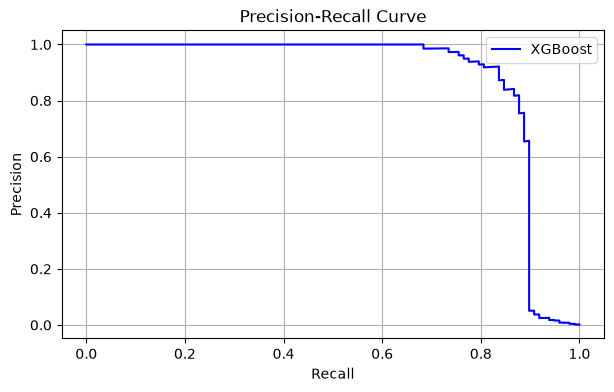

Optimal Decision Threshold: 0.8835
Max F1-Score: 0.8770

--- Classification Report (Tuned Threshold) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.84      0.88        98

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, classification_report

# Get XGBoost probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_probs)

# Plot PR Curve
plt.figure(figsize=(7, 4))
plt.plot(recalls, precisions, label='XGBoost', color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.legend()
plt.show()

# Threshold Tuning for Max F1-Score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Decision Threshold: {best_threshold:.4f}")
print(f"Max F1-Score: {f1_scores[best_idx]:.4f}\n")

# Evaluation with tuned threshold
custom_preds = (xgb_probs >= best_threshold).astype(int)
print("--- Classification Report (Tuned Threshold) ---")
print(classification_report(y_test, custom_preds))

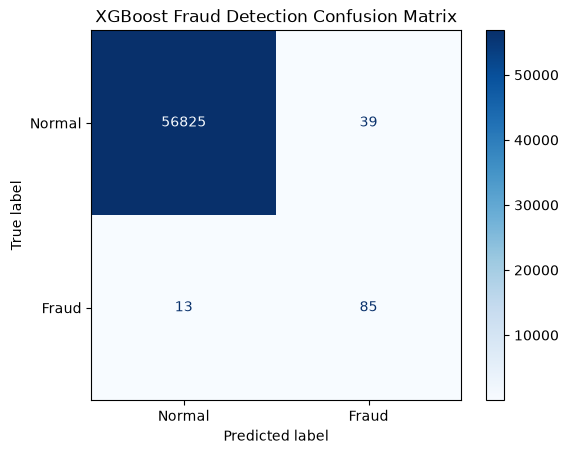

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, xgb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraud"])

disp.plot(cmap="Blues")
plt.title("XGBoost Fraud Detection Confusion Matrix")
plt.show()

In [16]:
import joblib, os

# Create directory inside current path or project root
os.makedirs("models", exist_ok=True)

# Save artifacts
joblib.dump(xgb_model, "models/xgb_fraud_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(best_threshold, "models/best_threshold.pkl")

print("All artifacts successfully saved to 'models/' directory!")

All artifacts successfully saved to 'models/' directory!
